# Section 00 - Getting ready

In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from plotnine import *
from sklearn.metrics import roc_curve, roc_auc_score

# Section 01 - Logistic regression on the Diabetes dataset

In this section we are considering the dataset pima-indians-diabetes.csv which is originally from
the National Institute of Diabetes and Digestive and Kidney Diseases. The objective of the dataset is
to diagnostically predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the dataset. A more detailed description of the data can be obtained from Kaggle:
https://www.kaggle.com/uciml/pima-indians-diabetes-database. For this dataset, the outcome is 0 or 1.

Load the dataset with the following lines of code:

In [5]:
diabetes = pd.read_csv('../Datasets/Exercise12/pima-indians-diabetes.csv')
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
feature_columns = [c for c in diabetes.columns if c != "Outcome"]

1. How balanced are the classes of the diabetes dataset?

In [10]:
class_counts = diabetes["Outcome"].value_counts().sort_index()
class_props = diabetes["Outcome"].value_counts(normalize=True).sort_index()

print(class_counts)
print(class_props)

Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


Roughly 1/3 of the dataset are diabetes cases, while the other 2/3 are healthy samples.

2. Create an appropriate plot to visualize the relationship between the Outcome variable and the feature
variables Glucose, BloodPressure and Insulin. What do you conclude from your visualization?

In [12]:
plot_df = diabetes[["Outcome", "Glucose", "BloodPressure", "Insulin"]].copy()
plot_df['Outcome'] = plot_df['Outcome'].astype(str)
plot_df.head()

,Outcome,Glucose,BloodPressure,Insulin
0,1,148,72,0
1,0,85,66,0
2,1,183,64,0
3,0,89,66,94
4,1,137,40,168


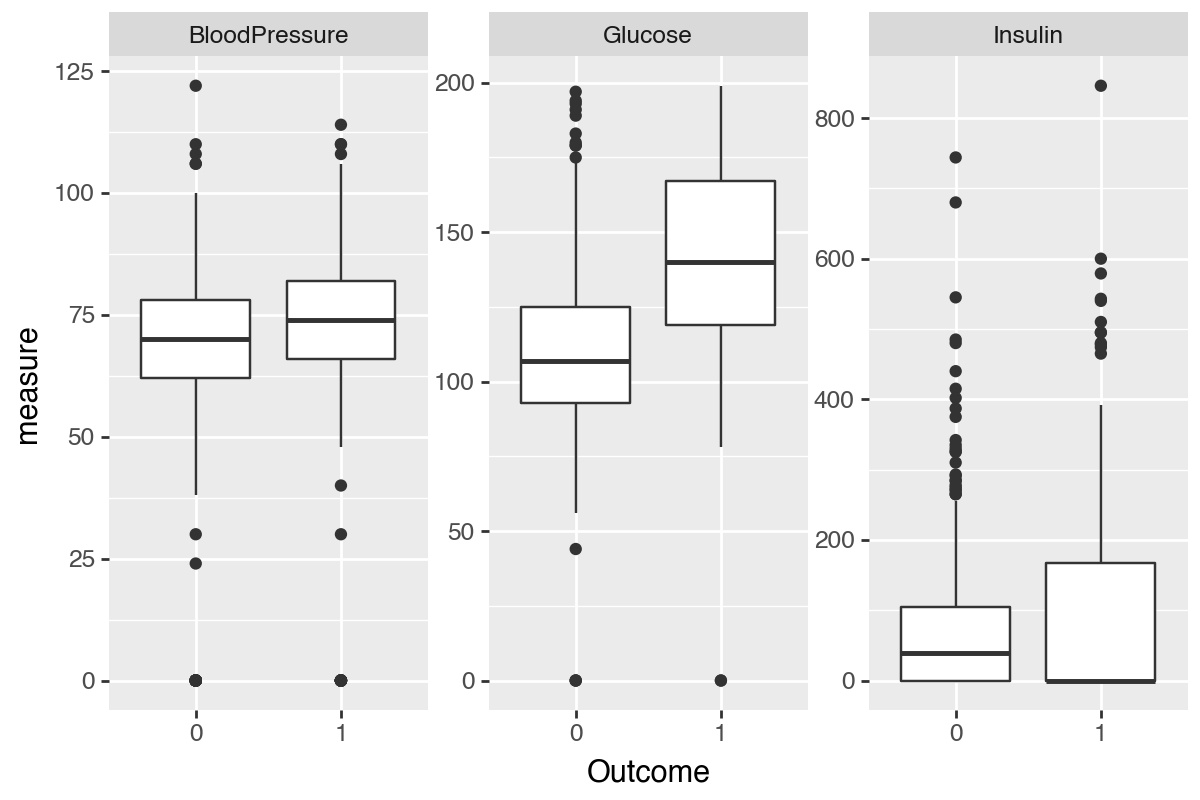

In [17]:
melted_plot = plot_df.melt(id_vars= 'Outcome', value_name= 'measure', var_name= 'feature')

(
    ggplot(melted_plot, aes('Outcome', 'measure')) + 
    geom_boxplot() +
    facet_wrap('~feature', scales = 'free') + 
    theme(figure_size= (6,4))
)

Glucose typically shows the strongest separation between classes (least overlap).

3. Fit a logistic regression model for predicting Outcome only based on the feature Glucose. Inspect the
coefficients of the model’s predictors. According to the model, how much do the odds of getting diabetes
increase upon increasing the blood glucose level by 1 mg/dL?

In [31]:
logistic_regression_glucose = smf.glm('Outcome ~ Glucose', data = diabetes, family = sm.families.Binomial()).fit()

logistic_regression_glucose.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
               Results: Generalized linear model
===============================================================
Model:              GLM              AIC:            812.7196  
Link Function:      Logit            BIC:            -4280.4233
Dependent Variable: Outcome          Log-Likelihood: -404.36   
Date:               2026-02-11 18:17 LL-Null:        -496.74   
No. Observations:   768              Deviance:       808.72    
Df Model:           1                Pearson chi2:   1.14e+03  
Df Residuals:       766              Scale:          1.0000    
Method:             IRLS                                       
----------------------------------------------------------------
            Coef.   Std.Err.     z      P>|z|    [0.025   0.975]
----------------------------------------------------------------
Intercept  -5.3501    0.4208  -12.7131  0.0000  -6.1749  -4.5253
Glucose     0.0379    0.0033   11.6469  0.0000   0.0315   0.0442
===============================================================

"""

In [32]:
beta1 = logistic_regression_glucose.params['Glucose']

odds_multiplier_per_1mg = float(np.exp(beta1))

percent_increase_per_1mg = ( odds_multiplier_per_1mg - 1) * 100

print(
f"odds_multiplier_per_1mg: {odds_multiplier_per_1mg:.4f}\n"
f"({percent_increase_per_1mg:.2f}% increase in odds per +1 mg/dL)"
)

odds_multiplier_per_1mg: 1.0386
(3.86% increase in odds per +1 mg/dL)


4. Calculate the log-odds using the model from above for all samples in the dataset. Store the scores in a
new column of the dataset. Visualize the distributions of the scores with an appropriate plot. Which
type of distribution would you ideally expect?

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:985: FutureWarning: linear keyword is deprecated, use which="linear"


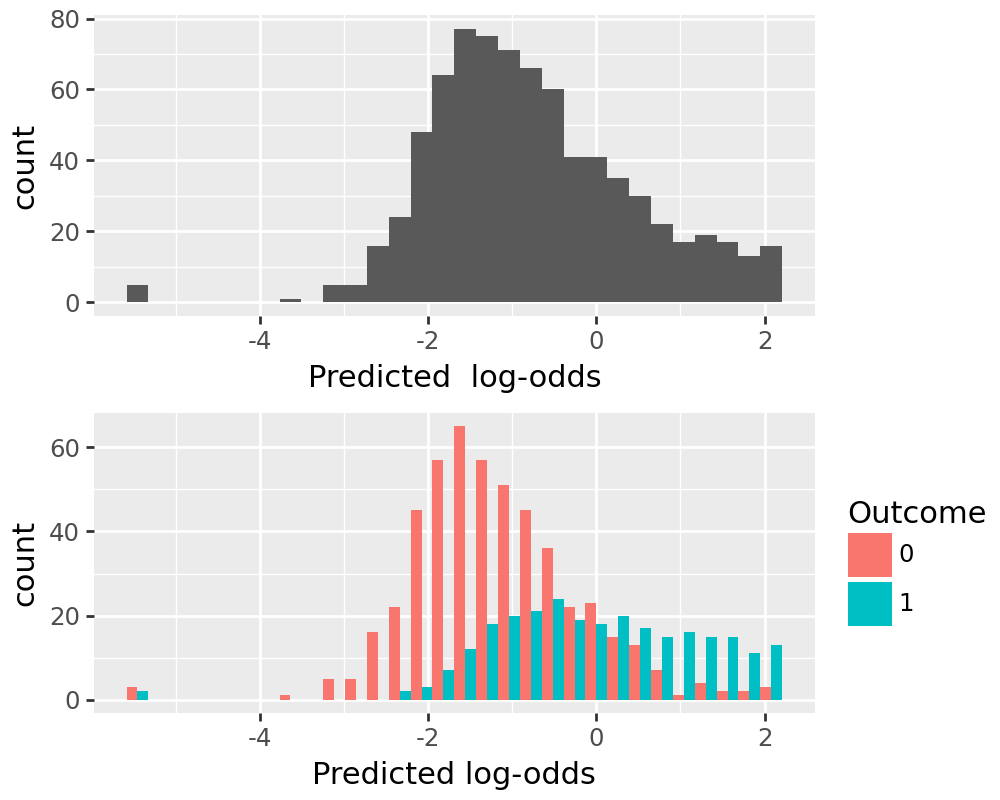

In [40]:
diabetes = diabetes.copy()
diabetes['score_glucose'] = logistic_regression_glucose.predict(diabetes, linear = True)

plot_df = diabetes.copy()
plot_df['Outcome'] = plot_df['Outcome'].astype(str)

p1 = (
    ggplot(plot_df, aes('score_glucose')) + 
    geom_histogram(bins = 30) + 
    labs(x = 'Predicted  log-odds') +
    theme(figure_size= (5,4))
)

p2 = (
    ggplot(plot_df, aes('score_glucose', fill = 'Outcome')) +
    geom_histogram(position = 'dodge', bins = 30) +
    labs(x = 'Predicted log-odds') +
    theme(figure_size=(5,4))
)

p1/p2

Ideally, we would like a bimodal distribution separating classes from positive and negative instances.

5. Create a function for computing the confusion matrix based on the predicted scores of a model and
the actual outcome. The function takes as input a threshold, a data table, the name of a scores column
and the name of a column with the actual labels. Then, compute the confusion matrix of the model for
the thresholds -1, 0 and 1. Are there any differences? What is the amount of false positives for the last
cutoff?

In [42]:
def confusion_matrix(df: pd.DataFrame, score_column: str,
labels_column: str,
threshold: float) -> pd.DataFrame:
    
    labels = df[labels_column].astype(int)
    pred_pos = (df[score_column] > threshold).astype(int)
    # rows: actual (0/1), cols: predicted positive? (0/1)
    cm = pd.crosstab(labels, pred_pos)
    cm.index = ["actual_0", "actual_1"]
    cm.columns = ["pred_0", "pred_1"]
    return cm

thresholds = [-1, 0, 1]
for t in thresholds:
    print("threshold =", t)
    print(confusion_matrix(diabetes, "score_glucose", "Outcome", t))
    false_positive_last = confusion_matrix(diabetes, "score_glucose", "Outcome", t).loc[
    "actual_0", "pred_1"]
    print({"false_positives_threshold_1": int(false_positive_last)})

threshold = -1
          pred_0  pred_1
actual_0     308     192
actual_1      55     213
{'false_positives_threshold_1': 192}
threshold = 0
          pred_0  pred_1
actual_0     443      57
actual_1     138     130
{'false_positives_threshold_1': 57}
threshold = 1
          pred_0  pred_1
actual_0     489      11
actual_1     203      65
{'false_positives_threshold_1': 11}


6. Create a second function for computing the TPR and FPR for a certain threshold, given predicted
scores and actual outcomes. What are TPR and FPR of the first model for thresholds -1, 0 and 1? Plot
these values in a scatter plot.

In [43]:
def tpr_fpr(df: pd.DataFrame, score_column: str,
labels_column: str, threshold: float) -> pd.DataFrame:
    cm = confusion_matrix(df, score_column, labels_column, threshold)
    
    tp = cm.loc["actual_1", "pred_1"]
    fp = cm.loc["actual_0", "pred_1"]
    tn = cm.loc["actual_0", "pred_0"]
    fn = cm.loc["actual_1", "pred_0"]
    
    tpr = tp / (tp + fn) if (tp + fn) else np.nan
    fpr = fp / (fp + tn) if (fp + tn) else np.nan
    return pd.DataFrame({"tpr": [tpr], "fpr": [fpr], "t": [threshold]})

In [44]:
thresholds = [-1, 0, 1]
resulting_tpr_fpr = []

for t in thresholds:
    resulting_tpr_fpr.append(
        tpr_fpr(diabetes, "score_glucose", "Outcome", t))
    
dt = pd.concat(resulting_tpr_fpr, ignore_index=True)

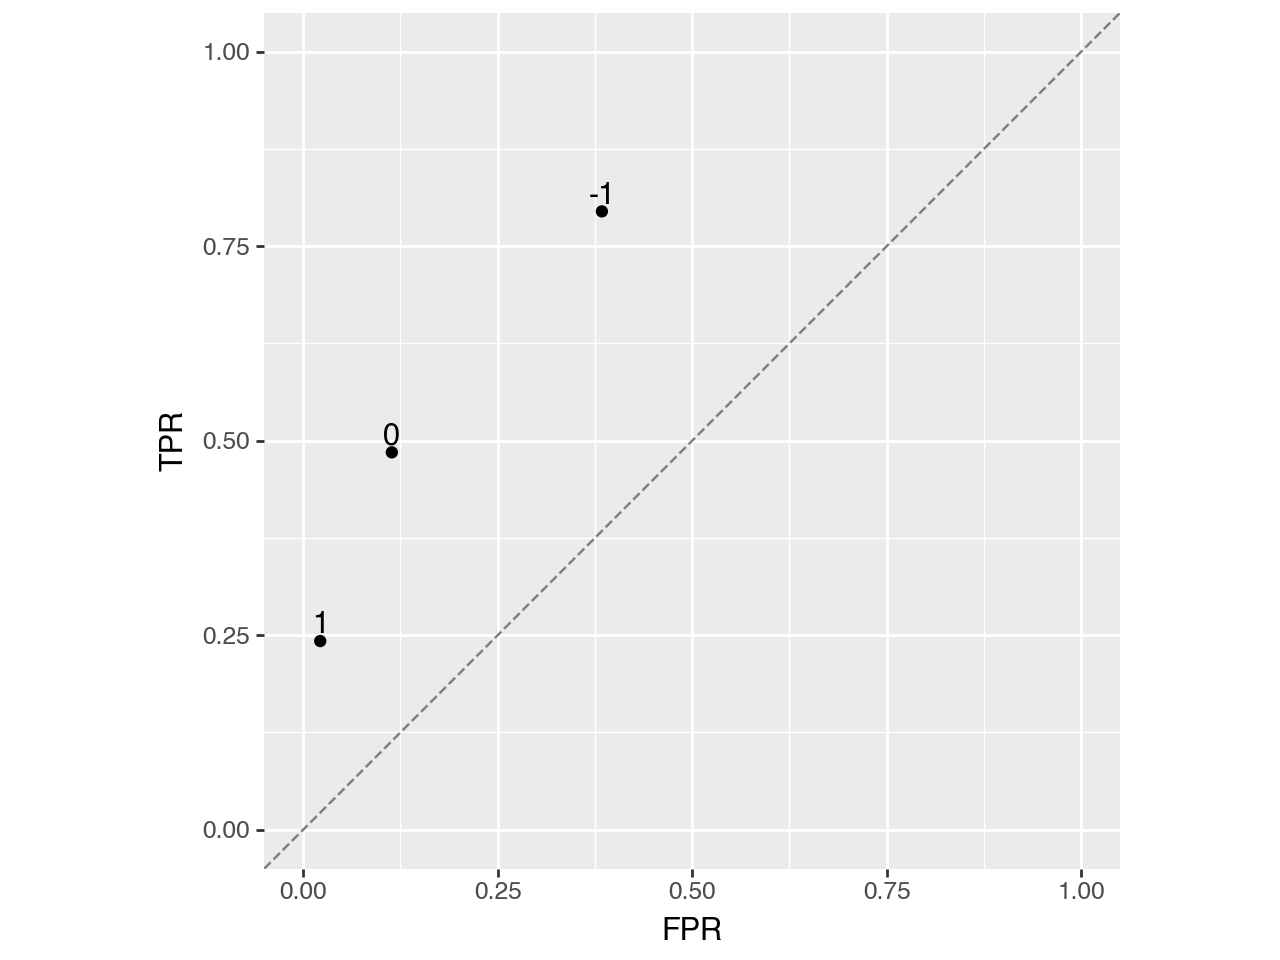

In [46]:
(
    ggplot(dt, aes("fpr", "tpr", label="t"))
    + geom_point()
    + geom_text(nudge_y=0.02)
    + geom_abline(linetype="dashed", color="gray")
    + coord_equal()
    + xlim(0, 1)
    + ylim(0, 1)
    + labs(x="FPR", y="TPR")
)

# Section 02 - Fitting and evaluating logistic models

In [47]:
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,score_glucose
0,6,148,72,35,0,33.6,0.627,50,1,0.255129
1,1,85,66,29,0,26.6,0.351,31,0,-2.130872
2,8,183,64,0,0,23.3,0.672,32,1,1.580685
3,1,89,66,23,94,28.1,0.167,21,0,-1.979380
4,0,137,40,35,168,43.1,2.288,33,1,-0.161474


1. Create two further logistic regression models for predicting Outcome. For one model, use only
BloodPressure. For the other model, use only Insulin. Which models have a significant feature?

In [ ]:
bloodPressure_model = smf.glm('Outcome ~ BloodPressure', data = diabetes, family = sm.families.Binomial()).fit()

insulin_model = smf.glm('Outcome ~ Insulin', data =diabetes, family = sm.families.Binomial()).fit()

In [52]:
bloodPressure_model.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
               Results: Generalized linear model
===============================================================
Model:              GLM              AIC:            994.1276  
Link Function:      Logit            BIC:            -4099.0154
Dependent Variable: Outcome          Log-Likelihood: -495.06   
Date:               2026-02-11 19:24 LL-Null:        -496.74   
No. Observations:   768              Deviance:       990.13    
Df Model:           1                Pearson chi2:   770.      
Df Residuals:       766              Scale:          1.0000    
Method:             IRLS                                       
---------------------------------------------------------------
                 Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
---------------------------------------------------------------
Intercept       -1.1401   0.2998 -3.8026 0.0001 -1.7277 -0.5525
BloodPressure    0.0074   0.0041  1.7929 0.0730 -0.0007  0.0155
===============================================================

"""

In [53]:
insulin_model.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
               Results: Generalized linear model
===============================================================
Model:              GLM              AIC:            984.8104  
Link Function:      Logit            BIC:            -4108.3325
Dependent Variable: Outcome          Log-Likelihood: -490.41   
Date:               2026-02-11 19:24 LL-Null:        -496.74   
No. Observations:   768              Deviance:       980.81    
Df Model:           1                Pearson chi2:   769.      
Df Residuals:       766              Scale:          1.0000    
Method:             IRLS                                       
----------------------------------------------------------------
             Coef.   Std.Err.     z     P>|z|    [0.025   0.975]
----------------------------------------------------------------
Intercept   -0.8145    0.0944  -8.6321  0.0000  -0.9994  -0.6296
Insulin      0.0023    0.0007   3.5177  0.0004   0.0010   0.0036
===============================================================

"""

In [56]:
p_bp = float(bloodPressure_model.pvalues["BloodPressure"])
p_ins = float(insulin_model.pvalues["Insulin"])
p_glucose = float(logistic_regression_glucose.pvalues["Glucose"])
print(f"p_BloodPressure: {p_bp}\np_Insulin: {p_ins}")
print(f"p_Glucose: {p_glucose}")

p_BloodPressure: 0.07299361892627039
p_Insulin: 0.00043534546389503584
p_Glucose: 2.3807217162463112e-31


2. Collect the predictions of each model for all samples and store in separate columns. Visualize the
distributions of the scores.

In [61]:
diabetes = diabetes.copy()

diabetes['score_Glucose'] = logistic_regression_glucose.predict(diabetes, linear = True)
diabetes['score_BloodPressure'] = bloodPressure_model.predict(diabetes, linear = True)
diabetes['score_Insulin'] = insulin_model.predict(diabetes, linear = True)

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:985: FutureWarning: linear keyword is deprecated, use which="linear"
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:985: FutureWarning: linear keyword is deprecated, use which="linear"
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:985: FutureWarning: linear keyword is deprecated, use which="linear"


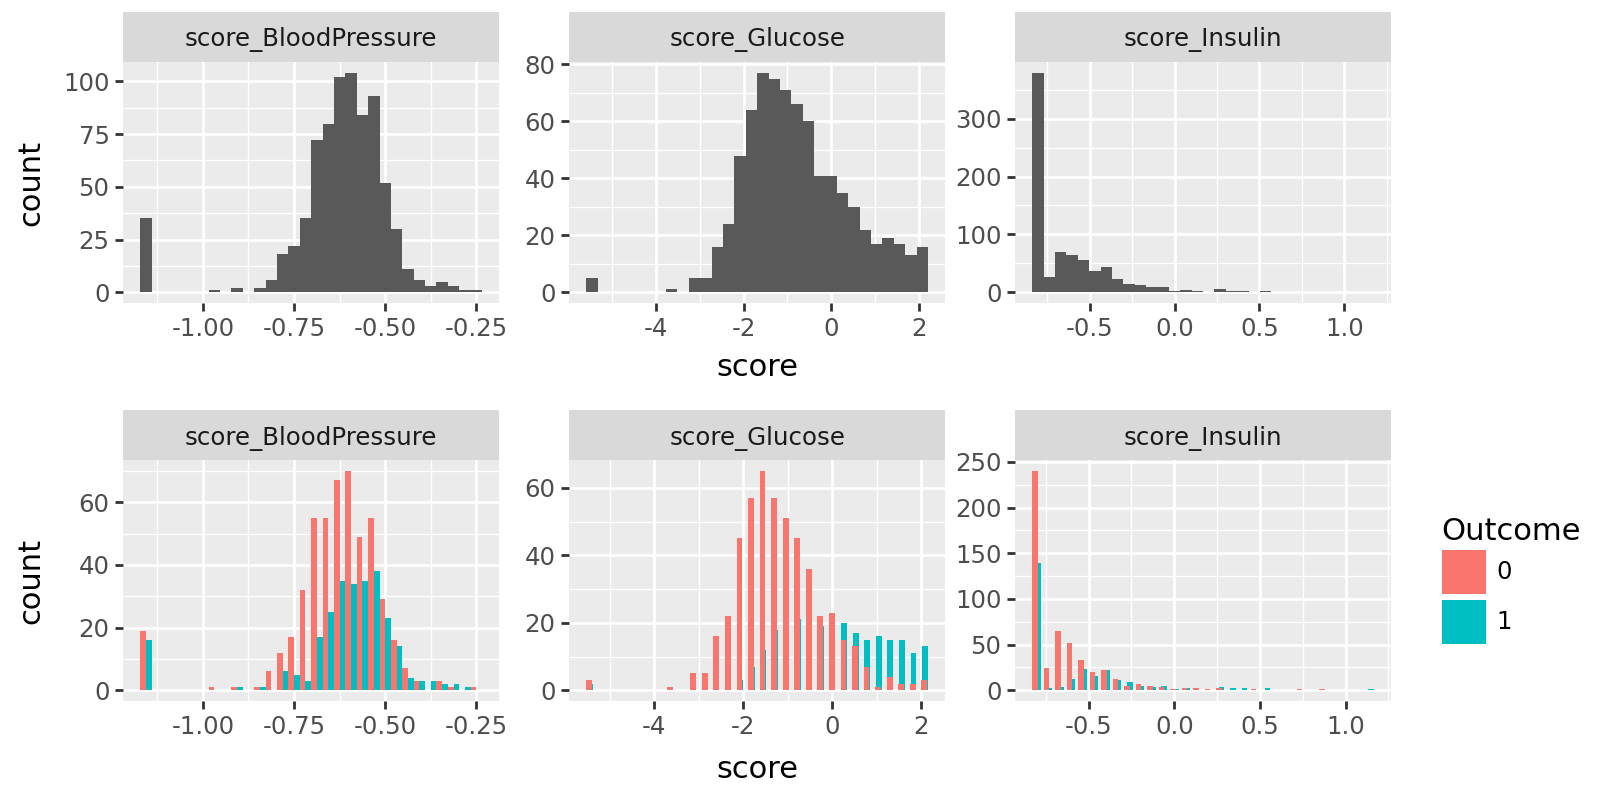

In [78]:
plot_long = diabetes[['Outcome', 'score_Glucose', 'score_BloodPressure', 'score_Insulin']].copy()
plot_long['Outcome'] = plot_long['Outcome'].astype('str')

plot_long = plot_long.melt(id_vars = 'Outcome', value_name= 'score', var_name= 'model')

p1 = (
    ggplot(plot_long, aes('score')) + 
    geom_histogram(bins = 30) + 
    facet_wrap('~model', scales= 'free') + 
    theme(figure_size= (6,4))
)

p2 = (
    ggplot(plot_long, aes('score', fill = 'Outcome')) + 
    geom_histogram(position = 'dodge', bins = 30) + 
    facet_wrap('~model', scales = 'free') +
    theme(figure_size= (8,4))
)

p1/p2

3. Plot a ROC curve for each model into a single plot. Add the area under the curve (AUC). Which is
the best model according to the AUC?

In [80]:
def roc_df_from_scores(y_true: pd.Series, scores: pd.Series,
model_name: str) -> pd.DataFrame:
    fpr, tpr, _ = roc_curve(y_true, scores)
    
    auc = roc_auc_score(y_true, scores)
    
    out = pd.DataFrame({"fpr": fpr, "tpr": tpr})
    out["model"] = f"{model_name} (AUC={auc:.4f})"
    return out

In [84]:
roc_plot_df = pd.concat(
[
    roc_df_from_scores(diabetes["Outcome"], diabetes["score_Glucose"], "Model Glucose"),
    roc_df_from_scores(diabetes["Outcome"], diabetes["score_BloodPressure"], "Model BloodPressure"),
    roc_df_from_scores(diabetes["Outcome"], diabetes["score_Insulin"], "Model Insulin"),
],
ignore_index=True,
)

roc_plot_df.head()

,fpr,tpr,model
0,0.000,0.000000,Model Glucose (AUC=0.7881)
1,0.000,0.003731,Model Glucose (AUC=0.7881)
2,0.000,0.007463,Model Glucose (AUC=0.7881)
3,0.002,0.018657,Model Glucose (AUC=0.7881)
4,0.002,0.029851,Model Glucose (AUC=0.7881)


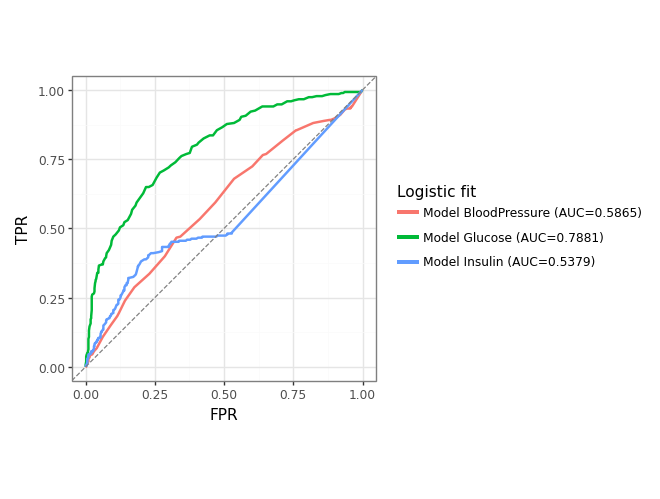

In [85]:
(
    ggplot(roc_plot_df, aes("fpr", "tpr", color="model"))
    + geom_line(size=1)
    + geom_abline(linetype="dashed", color="gray")
    + coord_equal()
    + xlim(0, 1)
    + ylim(0, 1)
    + labs(x="FPR", y="TPR", color="Logistic fit")
    + theme_bw()
).draw()

4. Fit a logistic regression model using all feature variables stored in feature_columns. Visualize the
distribution of the predicted scores for positive and negative classes. Plot again the ROC curves and
include the ROC curve of the full model.

In [86]:
full_formula = "Outcome ~ " + " + ".join(feature_columns)

In [87]:
logistic_regression_full = smf.glm(
full_formula, data=diabetes, family=sm.families.Binomial()).fit()
print(logistic_regression_full.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                Outcome   No. Observations:                  768
Model:                            GLM   Df Residuals:                      759
Model Family:                Binomial   Df Model:                            8
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -361.72
Date:                Wed, 11 Feb 2026   Deviance:                       723.45
Time:                        19:43:52   Pearson chi2:                     836.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.2964
Covariance Type:            nonrobust                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [89]:
diabetes = diabetes.copy()
diabetes["score_full"] = logistic_regression_full.predict(diabetes, linear=True)

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:985: FutureWarning: linear keyword is deprecated, use which="linear"


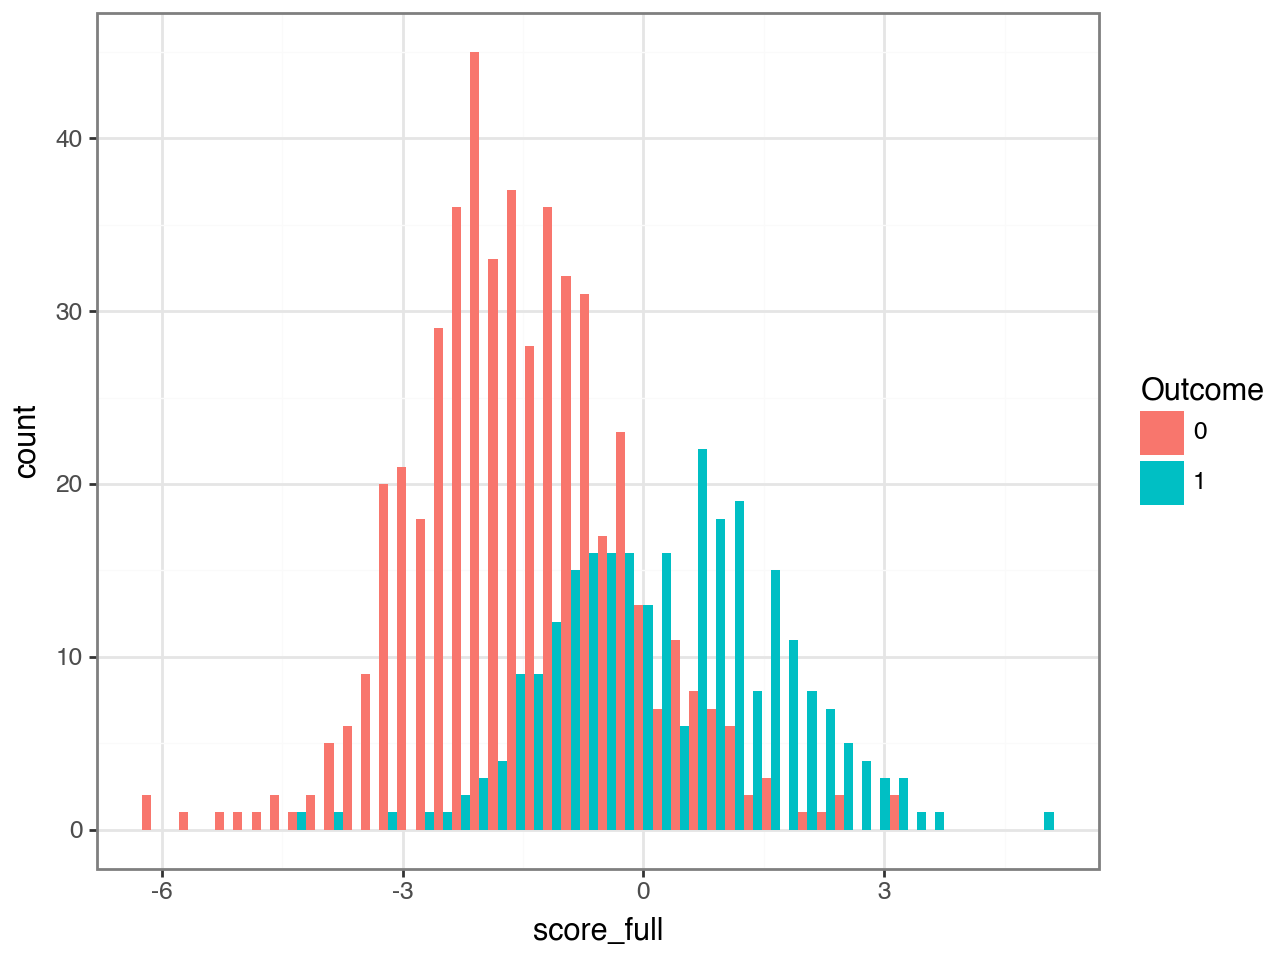

In [90]:
plot_df = diabetes[["Outcome", "score_full"]].copy()
plot_df["Outcome"] = plot_df["Outcome"].astype(str)

(
    ggplot(plot_df, aes("score_full", fill="Outcome"))
    + geom_histogram(position="dodge", bins=50)
    + theme_bw()
)

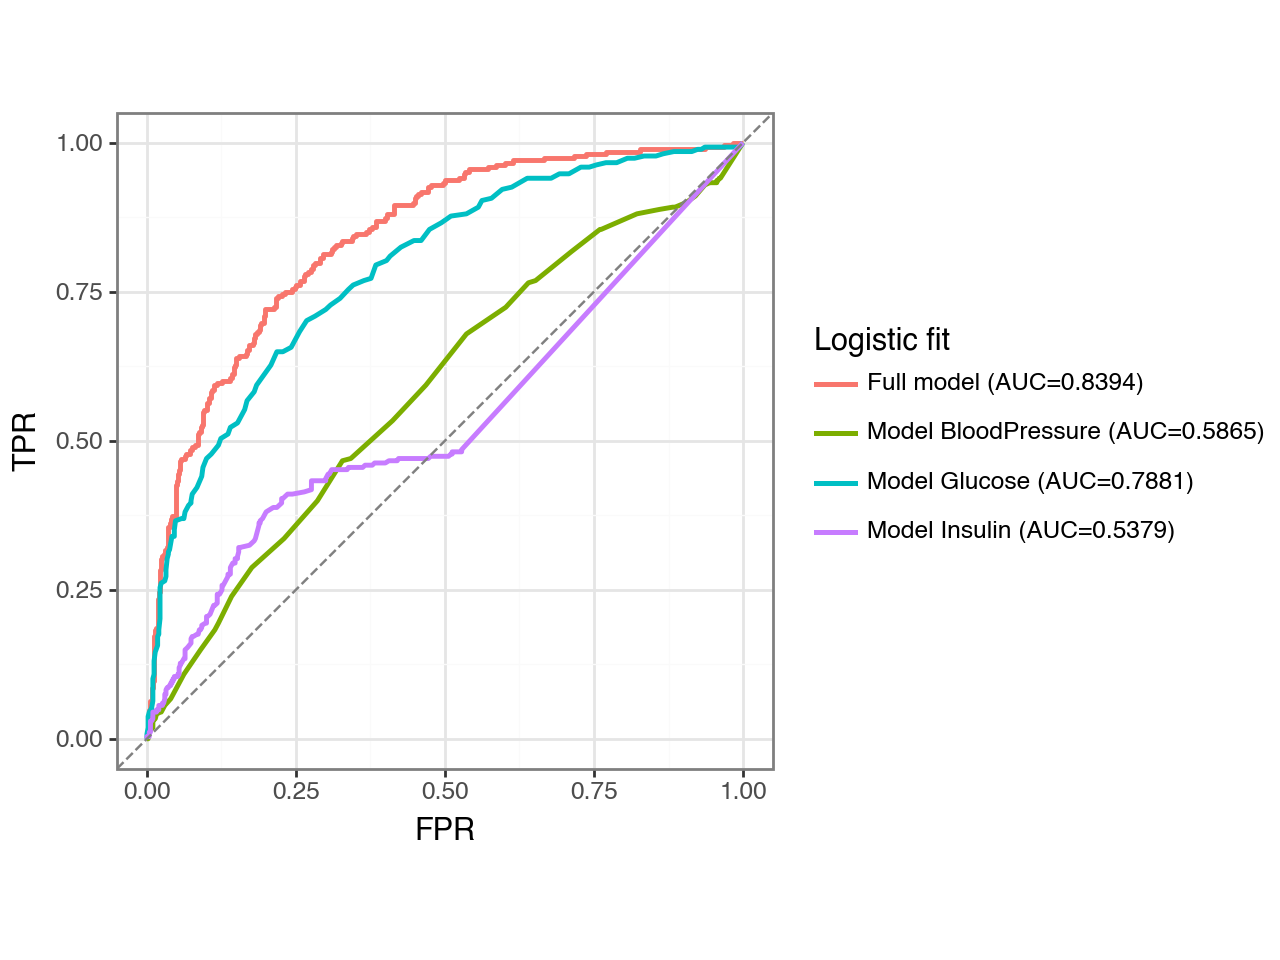

In [91]:
roc_plot_df_with_full = pd.concat(
[
    roc_plot_df,
    roc_df_from_scores(diabetes["Outcome"], diabetes["score_full"], "Full model"),
],  
ignore_index=True,
)


(
    ggplot(roc_plot_df_with_full, aes("fpr", "tpr", color="model"))
    + geom_line(size=1)
    + geom_abline(linetype="dashed", color="gray")
    + coord_equal()
    + xlim(0, 1)
    + ylim(0, 1)
    + labs(x="FPR", y="TPR", color="Logistic fit")
    + theme_bw()
)

2 - Interpreting logistic model parameters

Consider the output of a logistic model predicting sex based on body height.

<img src = '../images/Ekran Resmi 2026-02-11 19.49.11.png' width = 800>